In [1]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr


import os
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ.get("PATH", "")
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    #"font.serif": ["Times"],
    "text.latex.preamble": r"""
        \usepackage{amsmath}
        \usepackage{newtxtext,newtxmath}
    """,
})

In [2]:
def build_legend(ax, fontsize=12, framealpha=0.8, loc='best', textpad=0.1, borderpad=0.1):
    return ax.legend(
        edgecolor='black',  
        fontsize=fontsize,
        loc=loc,
        borderpad=borderpad,      # padding inside legend box
        labelspacing=0.1,   # vertical spacing between items
        handlelength=1.0,   # shorten handle
        handletextpad=textpad,
        framealpha=framealpha
            ).get_frame().set_boxstyle("square") 

def annotate_pearson(ax, x, y, locx=0.72, locy=0.08, boxcolor="#7e5d9c", facecolor='white', fontcolor='black', fontsize=15, alpha=0.8, pad=0.1):
    xlims, ylims = ax.get_xlim(), ax.get_ylim()
    xdiff, ydiff = xlims[1] - xlims[0], ylims[1] - ylims[0]
    loc_y = [xlims[0] + xdiff*(locx), ylims[0] + ydiff*(locy)]
    props = dict(boxstyle='square', facecolor=facecolor, edgecolor=boxcolor, alpha=alpha, pad=pad)
    ax.annotate(r'$\rho$ ='+f'{pearsonr(x, y)[0] : .2f}', loc_y, fontsize=fontsize, color=fontcolor, bbox=props)

In [3]:
surfaceData = pd.read_csv('../SurfaceFit/SurfaceFit.csv')
motionData = pd.read_csv('../PlaneMotion/PlaneMotion.csv')
data = pd.merge(surfaceData, motionData, on=['group', 'subject', 'sex', 'age', 'side', 'path', 'tpm_volume'])

c = {
    'blue': "#0097b2",
    'pink': "#cc79a7",
    'orange': "#e67a14",
    'green': "#009e73",
}

In [4]:
data.head()

,group,subject,sex,age,side,path,tpm_volume,tpm_kmin,tpm_kmax,mc1_kmin,...,C_pinch_load,C_grasp_load,C_jar_load,C_avg,C_fe,C_aa,R_fe,R_aa,int_fe,int_aa
0,CMC,14548,F,25,R,CMC_Tasks/Young/Female/14548/RightSTL,1440.57,-0.067296,0.161986,-0.051412,...,0.603004,0.699960,0.673624,0.645273,0.640169,0.630019,35.536284,44.364448,[-24.02208754 0.50407292 0.05492946],[-13.28888477 -0.72106355 2.69963404]
1,CMC,14613,M,52,R,CMC_Tasks/Old/Male/14613/RightSTL,3184.63,-0.058498,0.119960,-0.085605,...,0.691198,0.682719,0.696706,0.680244,0.688711,0.653336,41.095235,25.462683,[-30.63361415 -0.91721394 -0.91195567],[-18.04564175 -1.15106835 1.01009601]
2,CMC,14685,F,23,R,CMC_Tasks/Young/Female/14685/RightSTL,2005.73,-0.072100,0.178106,-0.073105,...,0.627587,0.690582,0.629994,0.635927,0.644008,0.606566,40.857682,35.768767,[-25.39041407 -0.84559511 -0.4983135 ],[-15.41484522 -1.45335176 2.43339456]
3,CMC,14726,M,48,R,CMC_Tasks/Old/Male/14726/RightSTL,3500.61,-0.075875,0.130703,-0.052299,...,0.639055,0.672300,0.670570,0.662201,0.674102,0.637793,26.380963,44.138019,[-30.47837509 0.6555277 -0.14887725],[-13.80863685 1.30284305 7.34277164]
4,CMC,14727,F,47,R,CMC_Tasks/Old/Female/14727/RightSTL,2320.74,-0.051320,0.170361,-0.095304,...,0.618754,0.640799,0.588887,0.637636,0.667327,0.661511,27.323843,17.484945,[-29.14613068 -2.87759819 -0.47104203],[-15.57513227 -0.33000412 1.49653314]


In [5]:
mask_young = data.age < 45
mask_male = data.sex == 'M'

# Scatter plots

In [6]:
x, y = data['C_avg'], data['R_fe']
x_y, y_y = x[mask_young], y[mask_young]
x_o, y_o = x[~mask_young], y[~mask_young]
x_m, y_m = x[mask_male], y[mask_male]
x_f, y_f = x[~mask_male], y[~mask_male]
x_ym, y_ym = x[(mask_male)&mask_young], y[(mask_male)&mask_young]
x_yf, y_yf = x[~mask_male&(mask_young)], y[~mask_male&(mask_young)]
x_om, y_om = x[(mask_male)&(~mask_young)], y[(mask_male)&(~mask_young)]
x_of, y_of = x[(~mask_male)&(~mask_young)], y[(~mask_male)&(~mask_young)]

#### Abstract plot
 - correlation coefficient is slightly different because this data used neutral-11 if it exists

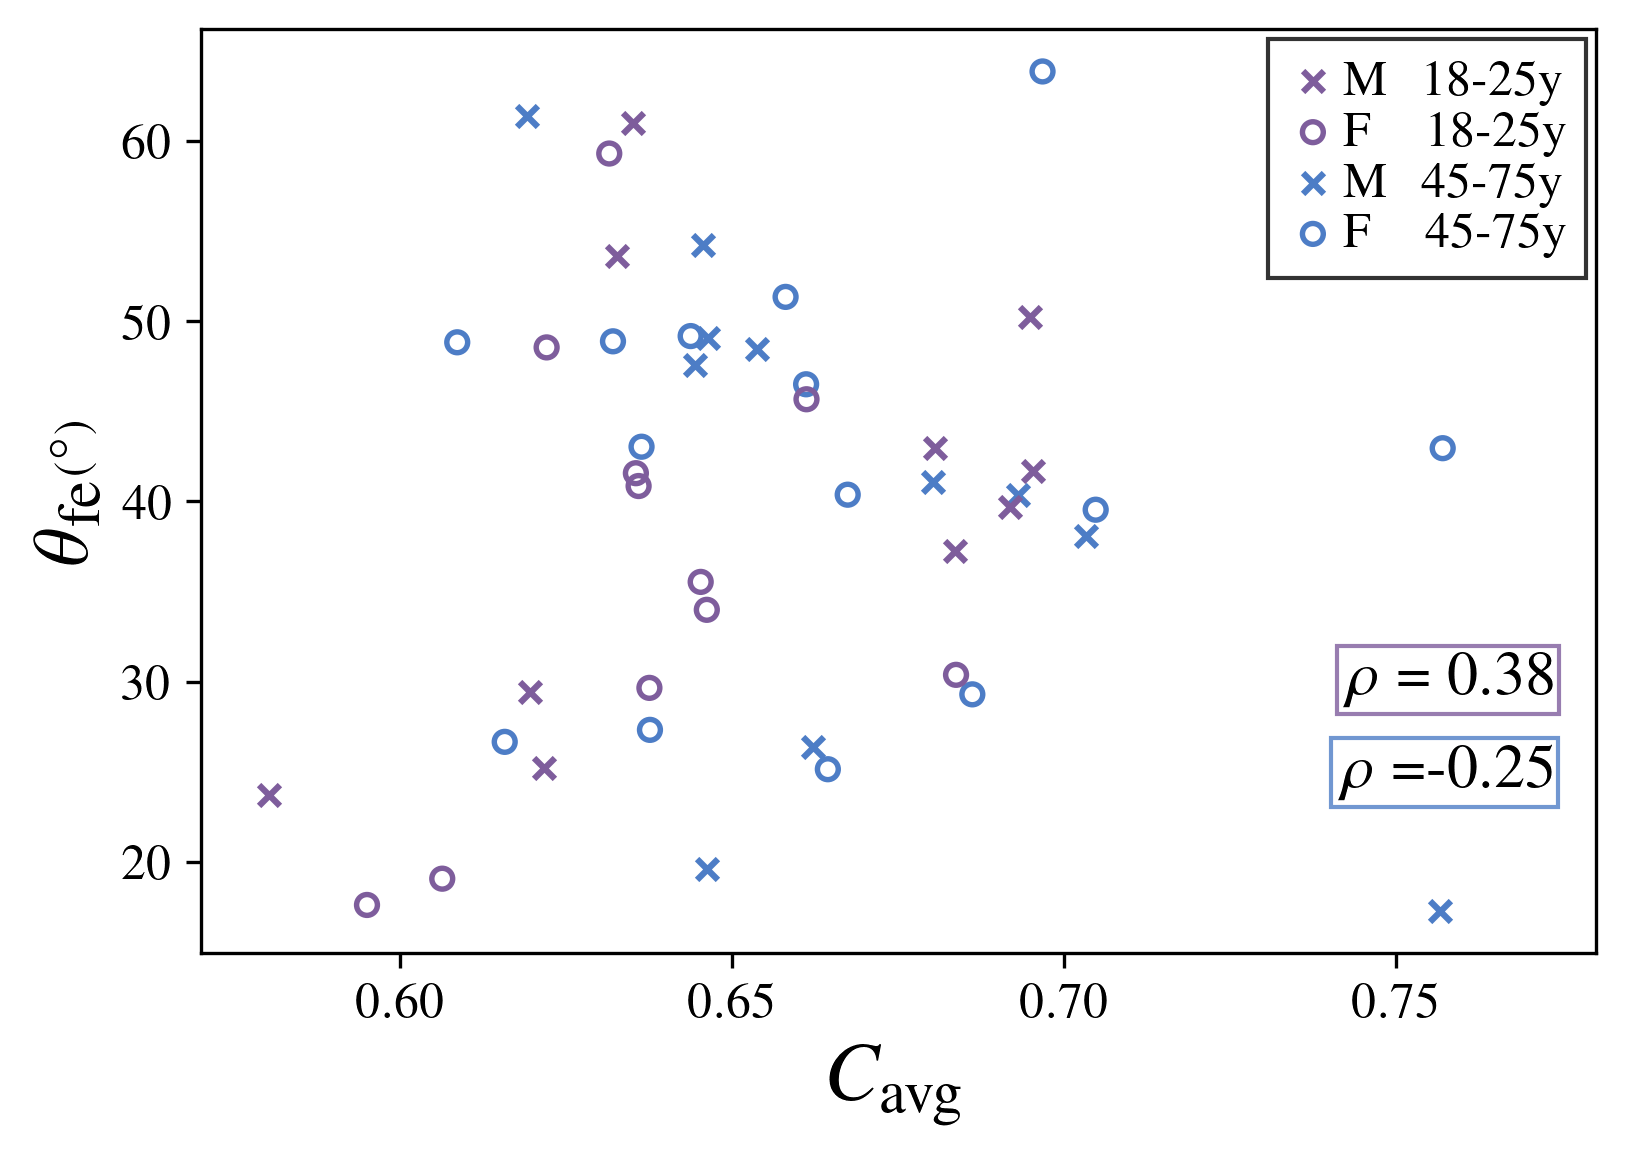

In [7]:
s = 25
figsize=(6, 4)
locx, locy = 0.72, 0.08 # correlation coeff label location

fig, ax = plt.subplots(figsize=figsize, dpi=300)

# 18-25
ax.scatter(x_ym, y_ym, s=s, marker='x', c="#7e5d9c", label=r'M \, 18-25y', zorder=3)
ax.scatter(x_yf, y_yf, s=s, marker='o', facecolors='none',edgecolors="#7e5d9c", linewidths=1.3, label=r'F \, \, 18-25y', zorder=3)
# 45-75
ax.scatter(x_om, y_om, s=s, marker='x', c="#4d7dc6", label=r'M \, 45-75y', zorder=0)
ax.scatter(x_of, y_of, s=s, marker='o', facecolors='none', edgecolors="#4d7dc6", linewidths=1.3, label=r'F \, \, 45-75y', zorder=0)

ax.set_xlabel(r'$C_{\text{avg}}$', fontsize=20)
ax.set_ylabel(r'$\theta_{\text{fe}}{\scriptscriptstyle (^\circ)}$', fontsize=20)

ax.set_xlim([0.57, 0.78])
ax.set_xticks([0.6, 0.65, 0.7, 0.75])
ax.tick_params(axis='both', which='major', labelsize=12)

annotate_pearson(ax, x_y, y_y, locx=locx+0.099, locy=locy+0.2)
annotate_pearson(ax, x_o, y_o, locx=locx+0.095, locy=locy+0.1, boxcolor="#4d7dc6")

legend = build_legend(ax)

plt.show()

#### Just young subjects - used in poster

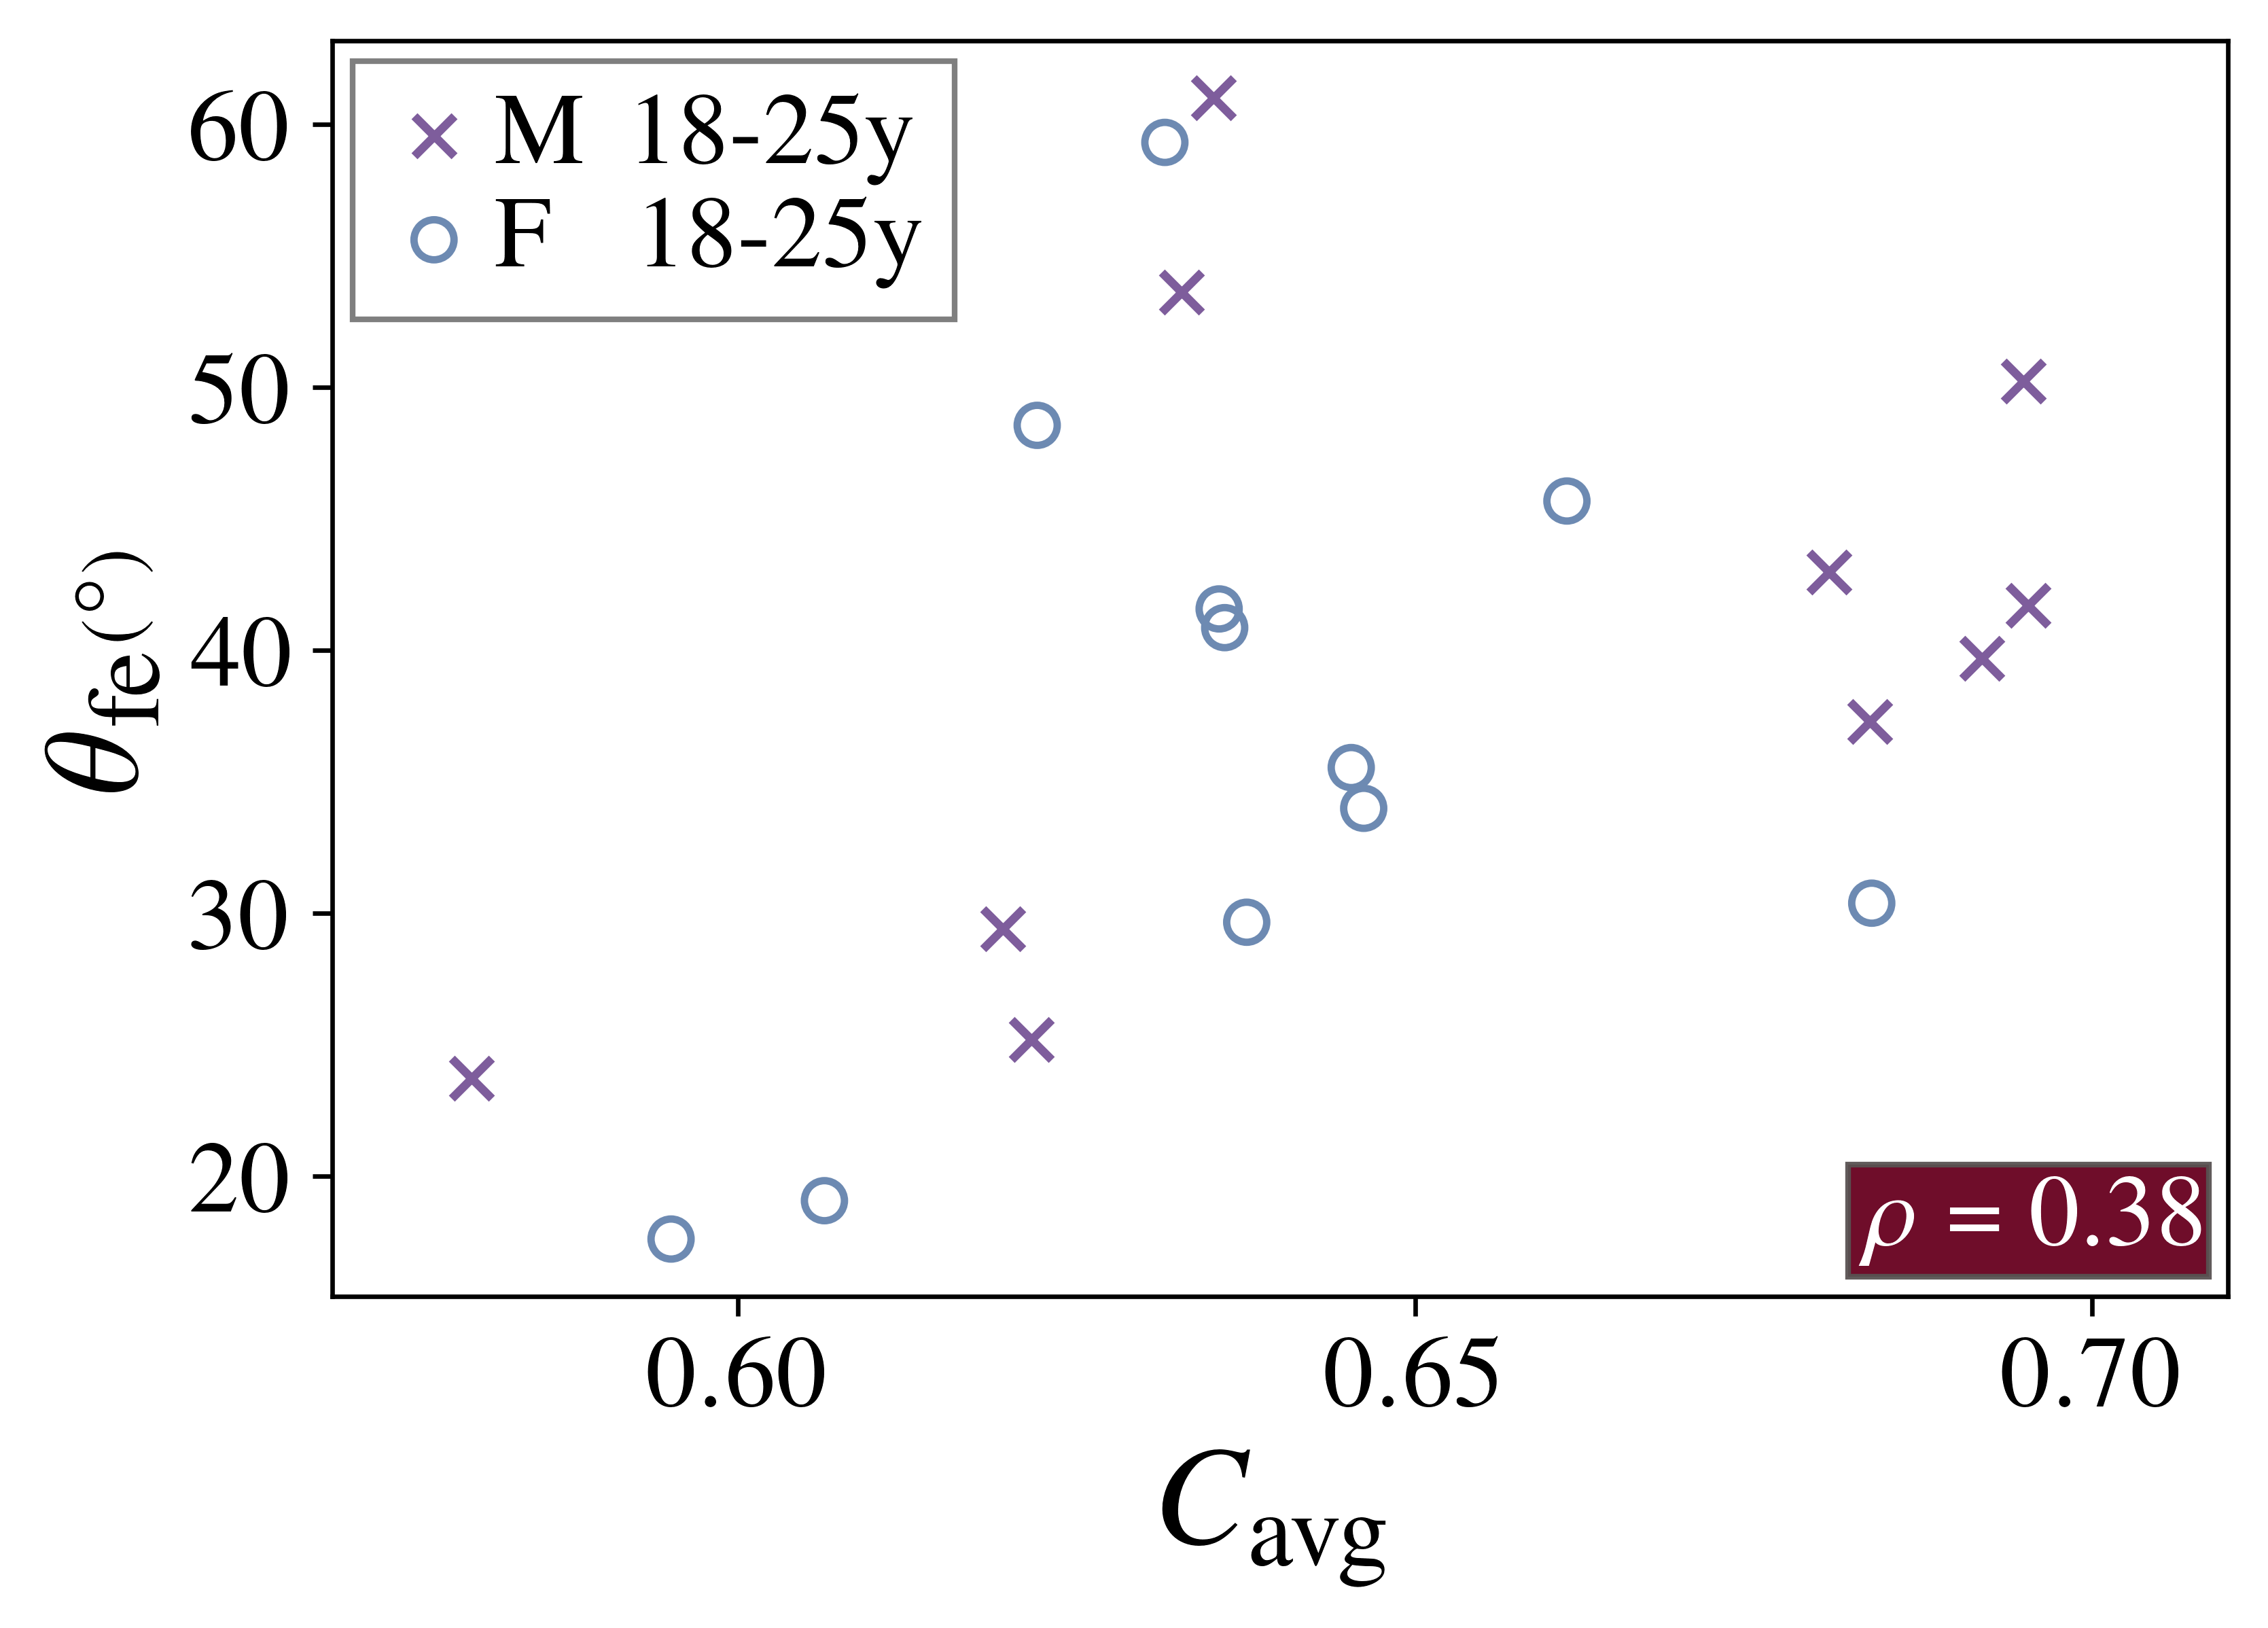

In [8]:
s = 50
fs1 = 25
fs2 = 18
figsize=(6, 4)

fig, ax = plt.subplots(figsize=figsize, dpi=600)

# 18-25
ax.scatter(x_ym, y_ym, s=s, marker='x', c="#7e5d9c", label=r'M \,18-25y', zorder=3)
ax.scatter(x_yf, y_yf, s=s, marker='o', facecolors='none',edgecolors="#6D8AB2", linewidths=1.3, label=r'F \, \,18-25y', zorder=3)

ax.set_xlabel(r'$C_{\text{avg}}$', fontsize=fs1)
ax.set_ylabel(r'$\theta_{\text{fe}}{\scriptscriptstyle (^\circ)}$', fontsize=fs1)

ax.set_xlim([0.57, 0.71])
ax.set_xticks([0.6, 0.65, 0.7])
ax.tick_params(axis='both', which='major', labelsize=fs2)

#annotate_pearson(ax, x_y, y_y, locx=locx+0.085, locy=locy-0.039, boxcolor='black', alpha=0.5, fontsize=fs2)
annotate_pearson(ax, x_y, y_y, locx=locx+0.085, locy=locy-0.039, boxcolor="#585252", facecolor="#67001E", alpha=0.95, fontcolor='white', fontsize=fs2)


legend = build_legend(ax, loc='upper left', framealpha=0.5, fontsize=fs2, borderpad=0.001)
#ax.set_title('Rotation vs. Congruence', fontsize=fs2)
plt.savefig('FEvsCy.pdf', bbox_inches='tight')
plt.show()

# Correlation coefficients

In [9]:
roms = [
    'R_fe', 
    'R_aa'
]
metrics = [
    #'tpm_volume',
    'tpm_kmax',
    'tpm_kmin',
    'mc1_kmax',
    'mc1_kmin',
    'C_avg',
    #'C_flexion',
    #'C_extension',
    #'C_abduction',
    #'C_adduction'
]

In [ ]:
mask_all = np.full(len(data), True)
masks = [mask_all, mask_young, ~mask_young, mask_male, ~mask_male]
mask_names = ['mask_all', 'mask_young', '~mask_young', 'mask_male', '~mask_male']

pmin = np.inf
dfs = []
for mask, mask_name in zip(masks, mask_names):
    corr_df = pd.DataFrame(index=roms, columns=metrics, dtype=float)
    for rom in roms:
        for metric in metrics:
            r, p = pearsonr(
                data.loc[mask, rom],
                data.loc[mask, metric]
            )
            corr_df.loc[rom, metric] = r
            if p < pmin: pmin = p
    dfs.append(corr_df)

    print('-'*6, mask_name, '-'*6)
    print(corr_df.round(2))
    #print(sorted([float(x) for x in corr_df.abs().round(2).values.flatten()], reverse=True)[:2])
    #print(round(corr_df.max().max(), 4))
    #print('p min:', round(pmin, 4))

------ mask_all ------
      tpm_kmax  tpm_kmin  mc1_kmax  mc1_kmin  C_avg
R_fe     -0.03      0.08     -0.20     -0.03   0.05
R_aa     -0.01     -0.12      0.14      0.14   0.11
------ mask_young ------
      tpm_kmax  tpm_kmin  mc1_kmax  mc1_kmin  C_avg
R_fe     -0.08     -0.00     -0.29     -0.31   0.38
R_aa      0.14     -0.16      0.22     -0.17   0.02
------ ~mask_young ------
      tpm_kmax  tpm_kmin  mc1_kmax  mc1_kmin  C_avg
R_fe      0.05      0.20     -0.09      0.18  -0.25
R_aa     -0.10     -0.09      0.10      0.35   0.17
------ mask_male ------
      tpm_kmax  tpm_kmin  mc1_kmax  mc1_kmin  C_avg
R_fe     -0.07      0.22     -0.16      0.25  -0.16
R_aa     -0.05     -0.20      0.10      0.07   0.24
------ ~mask_male ------
      tpm_kmax  tpm_kmin  mc1_kmax  mc1_kmin  C_avg
R_fe      0.03     -0.03     -0.24     -0.24   0.24
R_aa     -0.05     -0.08      0.13      0.18   0.01


In [11]:
pmin

np.float64(0.08808491303513505)

# Summary metrics table

In [17]:
cols = [
    'R_fe',
    'R_aa',
    'tpm_kmax',
    'tpm_kmin',
    'mc1_kmax',
    'mc1_kmin',
    'C_avg',
    'tpm_volume'
]
summary = data[cols].agg(["min", "mean", "max"])
summary.round(2)

,R_fe,R_aa,tpm_kmax,tpm_kmin,mc1_kmax,mc1_kmin,C_avg,tpm_volume
min,17.24,16.94,0.11,-0.12,0.09,-0.10,0.58,1230.74
mean,39.86,35.61,0.15,-0.07,0.12,-0.06,0.66,2086.74
max,63.87,48.25,0.18,-0.04,0.16,-0.02,0.76,3500.61


# logo

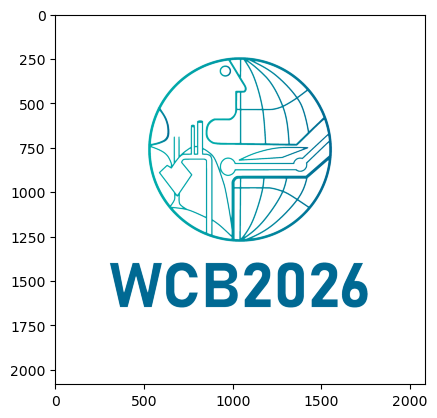

In [25]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("Logo-Package/WCB 2026 - Logo Package_White Round Icon-08.jpg").convert("RGBA")
arr = np.array(img)

# mask of white pixels
t = 30
white = (
    (arr[:, :, 0] > t) &
    (arr[:, :, 1] > t) &
    (arr[:, :, 2] > t)
)
# Set alpha to 0
arr[white, 3] = 0
# save
out = Image.fromarray(arr)
out.save("logo.png")

plt.imshow(arr)

In [20]:
arr[arr<200].max()

np.uint8(199)